# Images – To Do List



Prior to starting this problem, be sure to enable the GPU runtime processing in your Jupyter notebook.



## Problem Definition


Binary classification using pictures of dogs and cats in a NumPy Array to predict the image of a cat or a dog.  The target y is 1, and 0 for each animal and X = pictures.  After checking the plotted images, Cat = 1 and Dog = 0.


In [56]:
import pandas as pd
import numpy as np

## Data Collection



* Load pickled data from X.pickle and y.pickle from the AWS S3 bucket.



In [57]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [58]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

This is a four dimensional array with 24,946 images in the stack.  Each image is 100 pixels tall and 100 pixels wide and only 1 color channel, grayscale.

In [59]:
image_array.shape

(24946, 100, 100, 1)

Loading y pickled data.

In [60]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [61]:
target = pd.read_pickle( target_url )
type(target)


list

Single dog image

In [62]:
image_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg'

## Data Cleaning



* Scale the values in X so that they fall between 0 and 1 by dividing by 255.



In [63]:
#check array of image in index 0

image_array[0].shape

(100, 100, 1)

In [64]:
image_array = image_array / 255

In [65]:
image_array.max(), image_array.min()

(np.float64(1.0), np.float64(0.0))

check y list convert to array

In [66]:
target[0]

0

In [67]:
len(target)

24946

In [68]:
target = np.array(target)

In [69]:
target.shape

(24946,)

## Exploratory Data Analysis



* Look at the shape of X and y. Ensure that X is 4 dimensional.

* Plot a few ( >5 ) of the images in X using `plt.imshow()`.

* Look at the response values in y for those images.

* Hint: you may want to start with a random subset to get familiar with the process of building a NN.  Then go through the process again with the full set.



Look at the shape of X and y. Ensure that X is 4 dimensional.

In [70]:
image_array.shape

(24946, 100, 100, 1)

Check y shape, np.unique and target.sum for practice

In [71]:
target.shape

(24946,)

In [72]:
np.unique(target, return_counts = True)

(array([0, 1]), array([12470, 12476]))

In [73]:
target.sum()

np.int64(12476)

Plot a few ( >5 ) of the images in X using plt.imshow().

Mapping:


1.   Cats = 1
2.   Dogs = 0



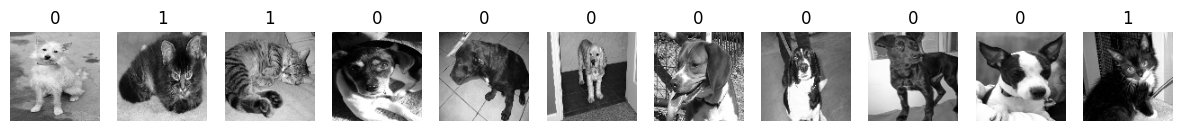

In [74]:
import matplotlib.pyplot as plt

# Create a grid for 11 images
fig, axes = plt.subplots(1, 11, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(image_array[i], cmap='gray')  # Display the image
    ax.axis("off")  # Hide the axis lines
    ax.set_title(target[i])


plt.show()

## Data Processing



* Split X and y into training and testing sets.

*  Build a convolutional neural network with the following:
  * Sequential layers
  * At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
  * A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
  * A dense output layer using the 'sigmoid' activation function.
  Note: you can play around with the number of layers and nodes to try to get better performance.

* Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

* Fit your model using the training set.

* Evaluate your model using the testing set.

* Plot the distribution of probabilities for the testing set.

* Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: [numpy.reshape]( https://numpy.org/doc/stable/reference/generated/numpy.reshape.html )

* Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

* Use the neural network you created to predict whether the image is a dog or a cat.



Split X and y into training and testing sets


In [75]:
from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing
image_array_train, image_array_test, target_train, target_test = train_test_split(
    image_array, target, test_size=0.2, random_state=42, stratify = target # stratify is not needed since y is balanced (array([0, 1]), array([12470, 12476])) including for practice
)

Convolutional neural network -
1. Sequential layers
2. At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
3. A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
4. A dense output layer using the 'sigmoid' activation function.

Note: you can play around with the number of layers and nodes to try to get better performance.

Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

In [76]:
import tensorflow as tf
from tensorflow.keras import layers, models
tf.random.set_seed(42)

# Initialize a sequential model
model = models.Sequential (
    [
        # First convolutional block: extracts 32 low-level features
        layers.Conv2D(
            32, (3, 3), activation="relu", input_shape=( 100, 100, 1)
        ),  # input_shape images
        layers.MaxPooling2D((2, 2)),
        # Second convolutional block: extracts 64 higher-level features
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Flattening the 2D maps into a 1D vector for classification
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        # Output layer: change units to match your number of classes
        layers.Dense(1, activation="sigmoid"),
    ]
)

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Print model summary to verify dimensions
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,185,729 (8.34 MB)

 Trainable params: 2,185,729 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

Fit your model using the training set.

In [77]:
history_5 = model.fit(
    image_array_train, target_train, epochs=5, validation_data=(image_array_test, target_test)
)

Epoch 1/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.6660 - loss: 0.5996 - val_accuracy: 0.7493 - val_loss: 0.5089
Epoch 2/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7727 - loss: 0.4773 - val_accuracy: 0.7725 - val_loss: 0.4706
Epoch 3/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8043 - loss: 0.4281 - val_accuracy: 0.7810 - val_loss: 0.4639
Epoch 4/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8299 - loss: 0.3853 - val_accuracy: 0.7840 - val_loss: 0.4633
Epoch 5/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8555 - loss: 0.3365 - val_accuracy: 0.7778 - val_loss: 0.4836


Evaluate your model using the testing set.

In [78]:
model.evaluate(image_array_test, target_test)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7778 - loss: 0.4836


[0.4836476147174835, 0.7777554988861084]

Plot the distribution of probabilities for the testing set.  Shows how confident the model is but does not mean it is correct or accurate

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


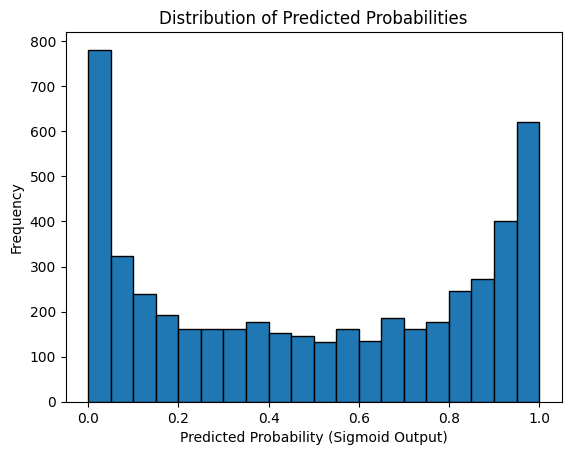

In [79]:
# Get the predictions and flatten them into a 1D array
probabilities = model.predict(image_array_test).flatten()

# Plot the probabilities using matplotlib's histogram
plt.hist(probabilities, bins=20, edgecolor="black")
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability (Sigmoid Output)")
plt.ylabel("Frequency")
plt.show()


Rerun sequential and compile

In [80]:
# Initialize a sequential
tf.random.set_seed(42)
model = models.Sequential(
 [    # First convolutional block: extracts 32 low-level features
      layers.Conv2D(
      32, (3, 3), activation="relu", input_shape=( 100, 100, 1)
      ),
      # input_shape images
            layers.MaxPooling2D((2, 2)),
      # Second convolutional block: extracts 64 higher-level features
           layers.Conv2D(64, (3, 3), activation="relu"),
      layers.MaxPooling2D((2, 2)),
      # Flattening the 2D maps into a 1D vector for classification
           layers.Flatten(),
      layers.Dense(64, activation="relu"),
      # Output layer: change units to match your number of classes
        layers.Dense(1, activation="sigmoid"),
 ]

)
# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

 # Print model summary to verify dimensions
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,185,729 (8.34 MB)

 Trainable params: 2,185,729 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
history_20 = model.fit(
    image_array_train, target_train, epochs=20, validation_data=(image_array_test, target_test)
)

Epoch 1/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6600 - loss: 0.6068 - val_accuracy: 0.7411 - val_loss: 0.5228
Epoch 2/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7611 - loss: 0.4950 - val_accuracy: 0.7647 - val_loss: 0.4875
Epoch 3/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8043 - loss: 0.4245 - val_accuracy: 0.7709 - val_loss: 0.4780
Epoch 4/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8475 - loss: 0.3425 - val_accuracy: 0.7754 - val_loss: 0.4922
Epoch 5/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8917 - loss: 0.2584 - val_accuracy: 0.7711 - val_loss: 0.5581
Epoch 6/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9191 - loss: 0.2007 - val_accuracy: 0.7649 - val_loss: 0.7028
Epoch 7/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9355 - loss: 0.1628 - val_accuracy: 0.7495 - val_loss: 0.8095
Epoch 8/20
624/624 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9526 - loss: 0.1245 - val_acc

In [82]:
model.evaluate(image_array_test, target_test)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7487 - loss: 1.6324


[1.6324317455291748, 0.7486974000930786]

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


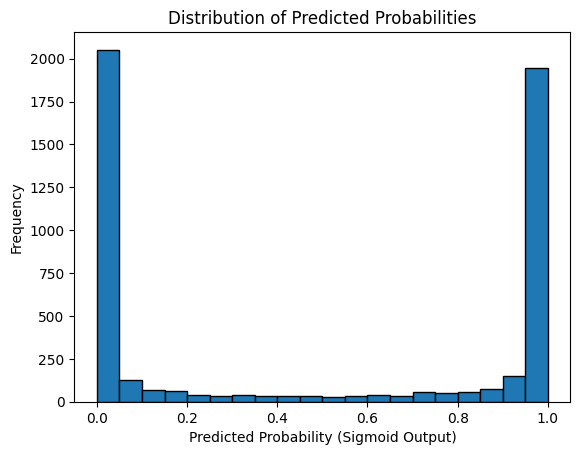

In [83]:
# the predictions and flatten them into a 1D array
probabilities = model.predict(image_array_test).flatten()

# Plot the probabilities using matplotlib's histogram
plt.hist(probabilities, bins=20, edgecolor="black")
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability (Sigmoid Output)")
plt.ylabel("Frequency")
plt.show()


Running Epoch 3 - the best model

In [84]:
# Initialize a sequential model
tf.random.set_seed(42)
model = models.Sequential (
    [
        # First convolutional block: extracts 32 low-level features
        layers.Conv2D(
            32, (3, 3), activation="relu", input_shape=( 100, 100, 1)
        ),  # input_shape images
        layers.MaxPooling2D((2, 2)),
        # Second convolutional block: extracts 64 higher-level features
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Flattening the 2D maps into a 1D vector for classification
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        # Output layer: change units to match your number of classes
        layers.Dense(1, activation="sigmoid"),
    ]
)

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Print model summary to verify dimensions
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,185,729 (8.34 MB)

 Trainable params: 2,185,729 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

In [85]:
history_20 = model.fit(
    image_array_train, target_train, epochs= 3, validation_data=(image_array_test, target_test)
)

Epoch 1/3
624/624 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6639 - loss: 0.5989 - val_accuracy: 0.7485 - val_loss: 0.5141
Epoch 2/3
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7695 - loss: 0.4831 - val_accuracy: 0.7727 - val_loss: 0.4677
Epoch 3/3
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8076 - loss: 0.4204 - val_accuracy: 0.7818 - val_loss: 0.4574


In [86]:
model.evaluate(image_array_test, target_test)

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7818 - loss: 0.4574


[0.45736902952194214, 0.7817635536193848]

156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


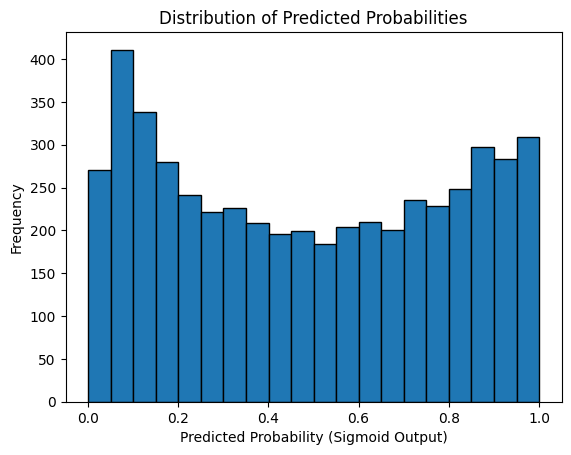

In [87]:
# the predictions and flatten them into a 1D array
probabilities = model.predict(image_array_test).flatten()

# Plot the probabilities using matplotlib's histogram
plt.hist(probabilities, bins=20, edgecolor="black")
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability (Sigmoid Output)")
plt.ylabel("Frequency")
plt.show()


Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: numpy.reshape

In [88]:
!curl -O {image_url}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 60603  100 60603    0     0   211k      0 --:--:-- --:--:-- --:--:--  212k


Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

In [89]:
import cv2


def prepare_image(filepath):
    # 1. read the file from disk, already in grayscale
    image_url = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

    # 2. resize to match training images
    image_url = cv2.resize(image_url, (100, 100))

    # 3. scale pixels the same way you scaled X
    image_url = image_url / 255.0

    # 4. reshape to a batch of one: (1, 100, 100, 1)
    image_url = image_url.reshape(1, 100, 100, 1)

    return image_url


In [90]:
dog = prepare_image('dog.jpg')
dog.shape

(1, 100, 100, 1)

Use the neural network you created to predict whether the image is a dog or a cat.  The model is showing that the image is mostly a cat.

In [91]:
model.predict(dog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


array([[0.21393372]], dtype=float32)

In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


All photos on these indices are dogs

In [93]:
np.where(target == 0)[0][:5]

array([0, 3, 4, 5, 6])

## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.

In [94]:
my_pet = prepare_image('/IMG_1934.JPG')
model.predict(my_pet)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0.82930607]], dtype=float32)

In [95]:
model.save('dogs_cats_cnn.keras')

## Communication of Results

### What I built
A convolutional neural network that looks at a 100x100 grayscale
picture and predicts whether it shows a dog (0) or a cat (1).
Trained on 19,957 images, tested on 4,989 it never saw.

### Baseline
The classes are almost perfectly balanced: 12,470 dogs and 12,476 cats.
A model that always guessed one animal would score about 50%. That is
the number to beat.

### Results

| Epochs | Test accuracy | Test loss |
|--------|---------------|-----------|
| 3      | 0.7764        | 0.4677    |
| 5      | 0.7741        | 0.5232    |
| 20     | 0.7631        | 1.7003    |

The 3-epoch model was the best on both measures. It beat the 50%
baseline by about 28 points, so the model learned something real.

### What surprised me
Training longer did not help. Accuracy stayed flat around 77-78%
across all three runs, but loss more than tripled at 20 epochs.
At epoch 17 the model got 99.89% of training images right while
still only getting 77% of unseen images right.

That is overfitting. The model stopped learning what dogs and cats
look like and started memorizing the specific training pictures.

If I had only watched accuracy, all three runs would have looked the
same. Loss is what showed the problem.

### The histograms
Each histogram shows how confident the model was on the test set.

- 3 epochs: thick middle. The model hedged on a lot of images.
- 5 epochs: middle thinning out.
- 20 epochs: middle nearly empty, huge spikes at 0 and 1.

The 20-epoch model looks the most confident and is the least accurate.
Confidence and correctness are not the same thing.

### Predictions on new images

| Image | Output | Model said | Truth | Result |
|-------|--------|-----------|-------|--------|
| dog.jpg | 0.686 | cat | dog | wrong |
| my cat photo | 0.802 | cat | cat | right |

One hit, one miss, which is about what a 78% model should do.
Neither prediction was emphatic. Both sat in the 0.6-0.8 range
rather than near 0 or 1.

### Limitations
- I used my test set as validation data during training, so the
  final accuracy is slightly optimistic. A proper three-way split
  would be more honest.
- I picked 3 epochs by looking at validation performance, which is
  the same data I reported accuracy on.
- Images are 100x100 grayscale. Color and higher resolution would
  likely help.